# Explore ingestion and alpha factors

Scratch notebook for pulling data through `src/data/ingest.py` and trying out the factor functions in `src/data/features.py` interactively. Nothing in here is part of the pipeline itself — it's just a place to poke at the functions and sanity-check the numbers.

Kernel: select **portfolio-constructor** (the project's `.venv`).

In [25]:
import sys
from pathlib import Path

# Notebooks run with the notebook's own directory as the working directory,
# so the project root (parent of notebooks/) needs to be on sys.path for
# `from src import ...` imports to resolve.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data import ingest, features

## 1. Pull data (cached after the first run)

In [26]:
tickers = config.TICKER_UNIVERSE + [config.BENCHMARK_TICKER]

prices_long = ingest.load_or_fetch_prices(tickers, config.DATA_START_DATE, config.DATA_END_DATE)
dividends = ingest.load_or_fetch_dividends(config.TICKER_UNIVERSE, config.DATA_START_DATE, config.DATA_END_DATE)

prices = ingest.to_wide_adj_close(prices_long)

print("prices_long:", prices_long.shape)
print("dividends:", dividends.shape)
print("prices (wide):", prices.shape)
prices.tail()

prices_long: (116240, 8)
dividends: (1614, 3)
prices (wide): (2906, 40)


ticker,AAPL,ABBV,AMZN,BA,BAC,CAT,COP,CSCO,CVX,DUK,...,SO,SPY,T,TSLA,UNH,UNP,VZ,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2026-07-20,326.589996,253.380005,249.990005,209.479996,60.419998,864.299988,115.680000,110.699997,189.710007,125.849998,...,94.459999,742.090027,21.950001,369.570007,421.549988,296.250000,43.500000,86.330002,112.199997,148.360001
2026-07-21,327.739990,256.100006,247.550003,204.800003,61.220001,889.969971,117.500000,112.180000,191.070007,125.910004,...,93.849998,748.280029,22.260000,378.929993,436.350006,293.130005,43.779999,87.739998,110.389999,151.710007
2026-07-22,325.890015,253.300003,244.850006,208.649994,61.619999,889.309998,118.790001,112.209999,192.979996,127.949997,...,95.800003,747.409973,23.040001,374.010010,431.309998,292.559998,44.290001,86.419998,109.330002,154.449997
2026-07-23,321.660004,256.920013,233.660004,209.229996,61.279999,894.539978,120.199997,112.760002,194.419998,129.259995,...,96.599998,738.179993,22.959999,319.690002,423.559998,304.329987,43.820000,86.190002,108.400002,156.889999
2026-07-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


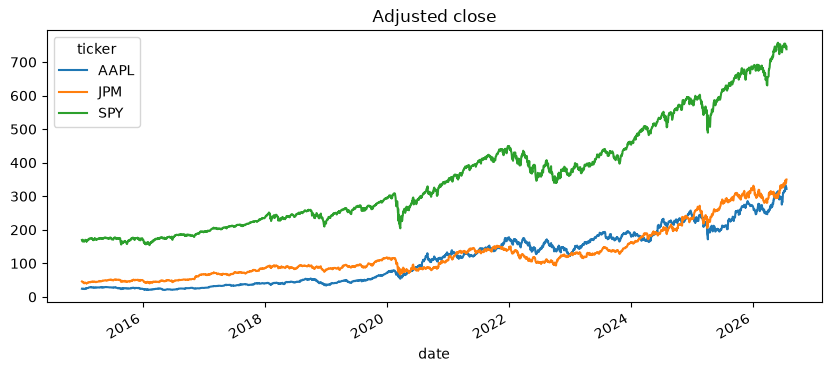

In [27]:
# Quick visual sanity check: do these look like real adjusted-close price series?
prices[["AAPL", "JPM", config.BENCHMARK_TICKER]].plot(figsize=(10, 4), title="Adjusted close")
plt.show()

## 2. Try the factor functions as of a given date

Each factor only uses price/dividend history strictly before `as_of_date` — change the date below and rerun to see the rankings shift.

In [ ]:
as_of_date = pd.Timestamp("2026-01-03")

momentum = features.compute_momentum(prices, as_of_date)
low_volatility = features.compute_low_volatility(prices, as_of_date)
dividend_yield = features.compute_dividend_yield(dividends, prices, as_of_date)

factor_table = pd.DataFrame(
    {"momentum": momentum, "low_volatility": low_volatility, "dividend_yield": dividend_yield}
).drop(index=config.BENCHMARK_TICKER, errors="ignore")

factor_table.sort_values("momentum", ascending=False)

,momentum,low_volatility,dividend_yield
ticker,,,
XOM,0.797579,0.022031,0.036164
COP,0.728637,0.027012,0.047343
CVX,0.572623,0.020760,0.036579
MRK,0.467800,0.012580,0.028058
ABBV,0.255622,0.014129,0.039873
CAT,0.167539,0.021191,0.020422
IBM,0.147039,0.015022,0.052870
KO,0.117265,0.012423,0.030686
PEP,0.102197,0.012282,0.028194


In [29]:
print("Top 5 momentum:")
print(factor_table["momentum"].sort_values(ascending=False).head())

print("\nTop 5 lowest volatility:")
print(factor_table["low_volatility"].sort_values().head())

print("\nTop 5 dividend yield:")
print(factor_table["dividend_yield"].sort_values(ascending=False).head())

Top 5 momentum:
ticker
XOM     0.797579
COP     0.728637
CVX     0.572623
MRK     0.467800
ABBV    0.255622
Name: momentum, dtype: float64

Top 5 lowest volatility:
ticker
JNJ    0.010986
PEP    0.012282
KO     0.012423
MCD    0.012490
MRK    0.012580
Name: low_volatility, dtype: float64

Top 5 dividend yield:
ticker
T       0.090217
VZ      0.083937
INTC    0.057287
IBM     0.052870
COP     0.047343
Name: dividend_yield, dtype: float64


## 3. Rank stocks and optimise a portfolio

Combine the three factors into one score, take the top `TOP_N_HOLDINGS`, then find mean-variance weights (Ledoit-Wolf shrinkage, max Sharpe) using the trailing `TRAIN_WINDOW_YEARS` of price history before `as_of_date` — the same window the real walk-forward backtest will use at each rebalance.

In [30]:
from src.models import ranker
from src.portfolio import optimise

# Use factor_table, not the raw momentum/low_volatility/dividend_yield series
# directly — factor_table already excludes the SPY benchmark column, and SPY
# must never be a candidate holding for the strategy itself.
scores = ranker.score_stocks(
    factor_table["momentum"], factor_table["low_volatility"], factor_table["dividend_yield"]
)
top_holdings = ranker.select_top_n(scores, n=config.TOP_N_HOLDINGS)

print(f"Top {config.TOP_N_HOLDINGS} holdings as of {as_of_date.date()}:")
print(list(top_holdings))

Top 15 holdings as of 2023-01-03:
['T', 'XOM', 'VZ', 'MRK', 'COP', 'IBM', 'CVX', 'ABBV', 'DUK', 'SO', 'KO', 'JNJ', 'PEP', 'MCD', 'PFE']


In [31]:
window_start = as_of_date - pd.DateOffset(years=config.TRAIN_WINDOW_YEARS)
training_prices = prices.loc[
    (prices.index >= window_start) & (prices.index < as_of_date), list(top_holdings)
]
print("training window:", training_prices.index.min().date(), "to", training_prices.index.max().date())

weights = optimise.max_sharpe_weights(training_prices)
weights_series = pd.Series(weights).sort_values(ascending=False)
weights_series[weights_series > 0]

training window: 2020-01-03 to 2022-12-30


XOM     0.15000
MRK     0.15000
ABBV    0.15000
PEP     0.15000
PFE     0.15000
MCD     0.10959
COP     0.08038
JNJ     0.06002
dtype: float64

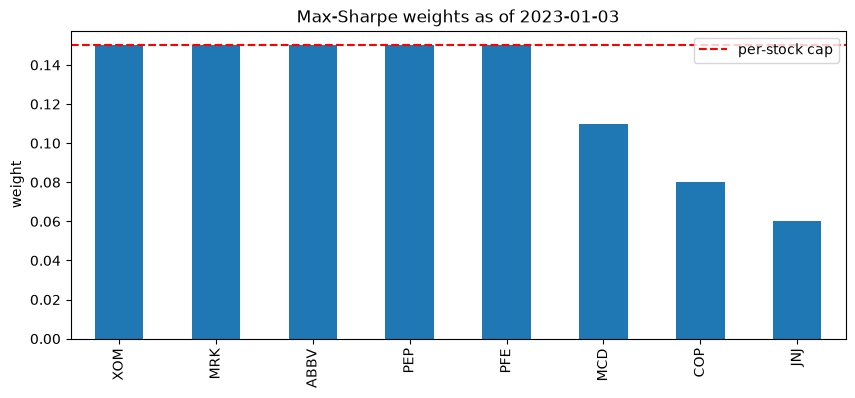

In [32]:
nonzero_weights = weights_series[weights_series > 0]
nonzero_weights.plot(
    kind="bar", figsize=(10, 4), title=f"Max-Sharpe weights as of {as_of_date.date()}"
)
plt.axhline(config.MAX_WEIGHT_PER_STOCK, color="red", linestyle="--", label="per-stock cap")
plt.legend()
plt.ylabel("weight")
plt.show()

## 4. Risk metrics

Turn the optimised weights into an actual daily return series, then run every metric in `src/risk/metrics.py` on it and compare against SPY.

Note: this holds the weights **statically over the whole available history** — it's a quick way to see the numbers, not the real walk-forward backtest (that rebalances monthly on a rolling training window, which is the next module to build).

In [ ]:
from src.risk import metrics

held_tickers = list(nonzero_weights.index)
weights_vector = nonzero_weights / nonzero_weights.sum()  # renormalise away any rounding

held_prices = prices[held_tickers].dropna()
portfolio_returns = held_prices.pct_change().dropna().dot(weights_vector)
spy_returns = prices[config.BENCHMARK_TICKER].pct_change().dropna()

print("portfolio daily returns:", portfolio_returns.shape)
portfolio_returns.tail()

In [ ]:
aligned_spy_returns = spy_returns.loc[portfolio_returns.index]

comparison = pd.DataFrame(
    {"strategy": metrics.compute_all(portfolio_returns), "SPY": metrics.compute_all(aligned_spy_returns)}
)
comparison

In [ ]:
cumulative_growth = pd.DataFrame(
    {"strategy": (1 + portfolio_returns).cumprod(), "SPY": (1 + aligned_spy_returns).cumprod()}
)
cumulative_growth.plot(figsize=(10, 4), title="Cumulative growth of $1 (static weights, not a real backtest)")
plt.show()

In [ ]:
# Visualise max_drawdown: how far below its own running peak the strategy ever fell.
running_peak = cumulative_growth["strategy"].cummax()
drawdown = (cumulative_growth["strategy"] - running_peak) / running_peak

drawdown.plot(figsize=(10, 3), title="Strategy drawdown from its own running peak", color="crimson")
plt.ylabel("drawdown")
plt.show()

print("max drawdown:", drawdown.min())

In [ ]:
tail_risk_rows = [
    "historical_var_95",
    "expected_shortfall_95",
    "historical_var_99",
    "expected_shortfall_99",
]
comparison.loc[tail_risk_rows].plot(
    kind="bar", figsize=(8, 4), title="Tail risk: VaR vs Expected Shortfall (CVaR)"
)
plt.ylabel("daily return")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()